In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

“Yahoo Finance in Python” usually means using Python code to access financial data from Yahoo Finance like stock prices, historical data, and company info.

Since Yahoo doesn’t offer an official public API, developers use unofficial libraries that pull data from it.
The popular library is yfinance.

In [11]:
#Get stock data for Apple and store it in a variable called ticker.
import yfinance as yf

In [12]:
ticker = yf.Ticker('AAPL')
df = ticker.history(period='1y')
df=df.reset_index()
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-04-21 00:00:00-04:00,192.431301,192.958999,188.986309,192.321777,46742500,0.0,0.0
1,2025-04-22 00:00:00-04:00,195.268944,200.715208,195.119601,198.873245,52976400,0.0,0.0
2,2025-04-23 00:00:00-04:00,205.106046,207.097367,201.919936,203.712128,52929200,0.0,0.0
3,2025-04-24 00:00:00-04:00,204.000880,207.923785,202.059345,207.465775,47311000,0.0,0.0
4,2025-04-25 00:00:00-04:00,205.474435,208.839773,205.305175,208.371811,38222300,0.0,0.0


<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Imported all the required libraries then loaded the stock data from python library(yfinance). 
Displayed the data by using head function of pandas.
</span><br>

<span style="color:black; font-weight:bold; font-size:20px;">Exploratory Data Analysis</span>

In [13]:
#No of rows and columns in the data
df.shape

(250, 8)

In [14]:
#No of observations/datapoints in the data
df.size

2000

In [15]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.0
mean,241.853718,244.281076,239.509209,241.934490,5.022552e+07,0.004160,0.0
std,27.595599,27.806036,27.382544,27.588505,1.875910e+07,0.032689,0.0
min,192.431301,192.958999,188.986309,192.321777,1.791060e+07,0.000000,0.0
25%,210.561737,213.021756,209.081249,211.705776,3.946608e+07,0.000000,0.0
50%,252.679148,255.191745,249.535004,252.224998,4.639285e+07,0.000000,0.0
75%,264.581520,268.280983,261.761216,264.684998,5.462505e+07,0.000000,0.0
max,285.932471,288.350192,283.035157,285.922455,1.637413e+08,0.260000,0.0


In [16]:
df.isnull().mean()*100

Date            0.0
Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64

<span style="color:black; font-weight:bold; font-size:18px;">Distribution of the Output</span>

In [17]:
X=df.drop(columns=['Date','Close' , 'Dividends' ,'Stock Splits'])
Y=df['Close']

In [18]:
X.head()

,Open,High,Low,Volume
0,192.431301,192.958999,188.986309,46742500
1,195.268944,200.715208,195.119601,52976400
2,205.106046,207.097367,201.919936,52929200
3,204.000880,207.923785,202.059345,47311000
4,205.474435,208.839773,205.305175,38222300


Text(0.5, 1.0, 'Box plot of Output(Close) for Outliers')

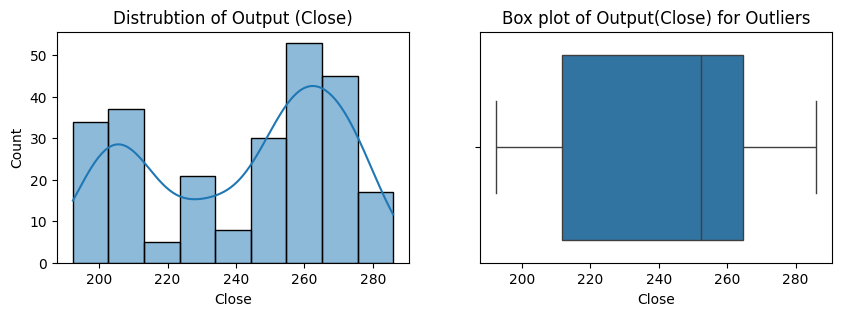

In [19]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sb.histplot(df['Close'], kde='True')
plt.title('Distrubtion of Output (Close)')


plt.subplot(1,2,2)
sb.boxplot(x=df['Close'])
plt.title('Box plot of Output(Close) for Outliers')

<span style="color:black; font-weight:bold; font-size:18px;">Distribution of the Iuputs</span>

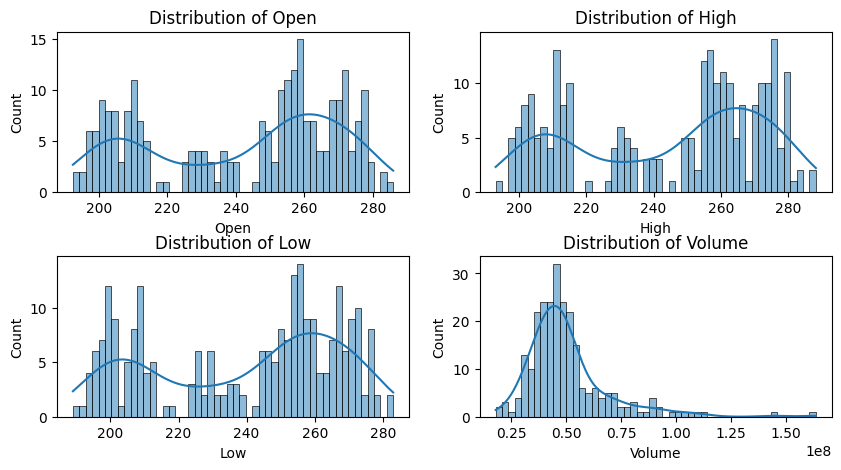

In [20]:
plt.figure(figsize=(10,5))
index=0
for i in X.columns:
    index+=1
    plt.subplot(2,2,index)
    sb.histplot(df[i], kde='True',bins=50)
    plt.title('Distribution of {}'.format(i))
    plt.subplots_adjust(hspace=0.4)

<span style="color:black; font-weight:bold; font-size:18px;">Relationship between Input & Output</span>

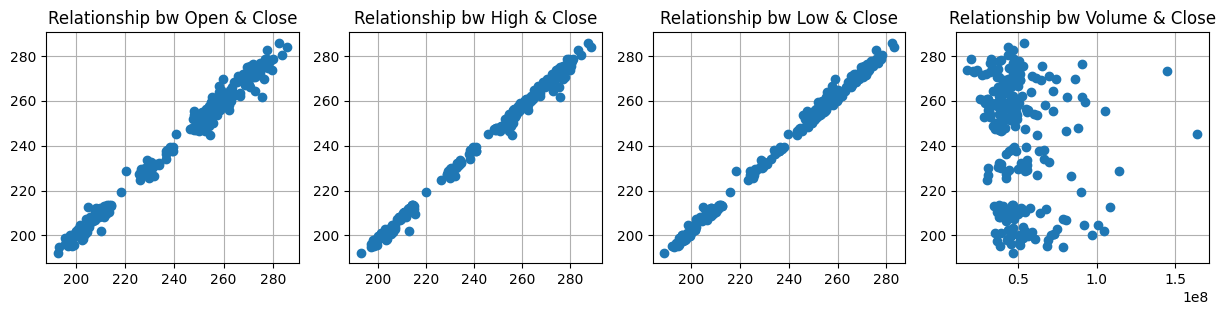

In [21]:
plt.figure(figsize=(15,3))
index=0
cols=[col for col in X]
for col in cols:
    index+=1
    plt.subplot(1,4,index)
    plt.scatter(x=df[col], y=df['Close'])
    plt.title('Relationship bw {} & Close'.format(col))
    plt.grid(True)
    plt.gca().set_axisbelow(True)

<span style="color:black; font-weight:bold; font-size:18px;">To check Multicolinearity </span>

In [22]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state=41,test_size=0.2)

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
l=[]
for i in range(x_train.shape[1]):
    l.append(variance_inflation_factor(x_train,i))
l

[np.float64(18144.595565917032),
 np.float64(23952.64804347193),
 np.float64(22294.14407798348),
 np.float64(8.979635024993994)]

In [24]:
pd.DataFrame({'l':l},index=x_train.columns).T

,Open,High,Low,Volume
l,18144.595566,23952.648043,22294.144078,8.979635


<Axes: >

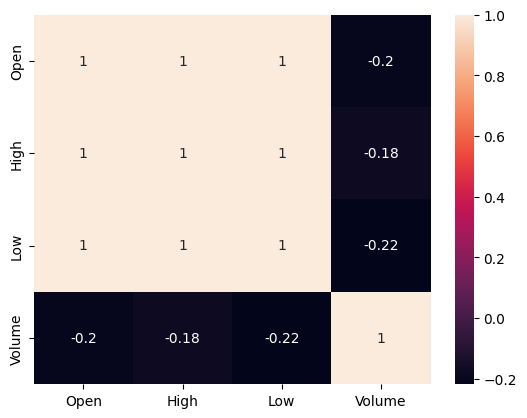

In [25]:
sb.heatmap(X.corr(),annot=True)

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Performed Exploratory Data Analysis:
1: Displayed the number of rows and columns, Observations/data points , Missing values, Information, Statistical summary of the data.
2: Picked few columns from the data. Displayed the distribution of the output column and Input columns, Relationship between Input and output and checked the multicolinearity between inputs.
Oberved that input data has four(4) columns, first 3 columns(open, High, Low) are bimodal Distribution and last column(Volume) is Righ skewed data. Output column(Close) distribution is a bimodal.

Plotted the graphs between input and output to see the relationship. So First three input columns and output is linear but last input column and output is non-linear realtionship.
Also there is no multicolinearity, Inputs are not dependent to each other, inputs are independent.
</span><br>

<span style="color:black; font-weight:bold; font-size:20px;">Train the Model</span>

In [40]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state=41,test_size=0.2)


In [41]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

<span style="color:black; font-weight:bold; font-size:18px;">Evaluate the Model </span>

In [42]:
#R2_score, Mean_squared_error, Mean_absolute_error
print('R2_score:', r2_score(y_test,y_pred))
print('MSE:', mean_squared_error(y_test,y_pred))
print('MAE:', mean_absolute_error(y_test,y_pred))

R2_score: 0.9982861611387716
MSE: 1.5257572776716908
MAE: 0.8736162824697692


<span style="color:black; font-weight:bold; font-size:18px;">Weights & Bias </span>

In [43]:
#Weights
print('Weights:',lr.coef_)
print('bias:', lr.intercept_)

Weights: [-4.63359037e-01  7.24395532e-01  7.37271872e-01  9.98479999e-09]
bias: -0.041034754075752744


<span style="color:black; font-weight:bold; font-size:18px;">Graphs of the Model </span>

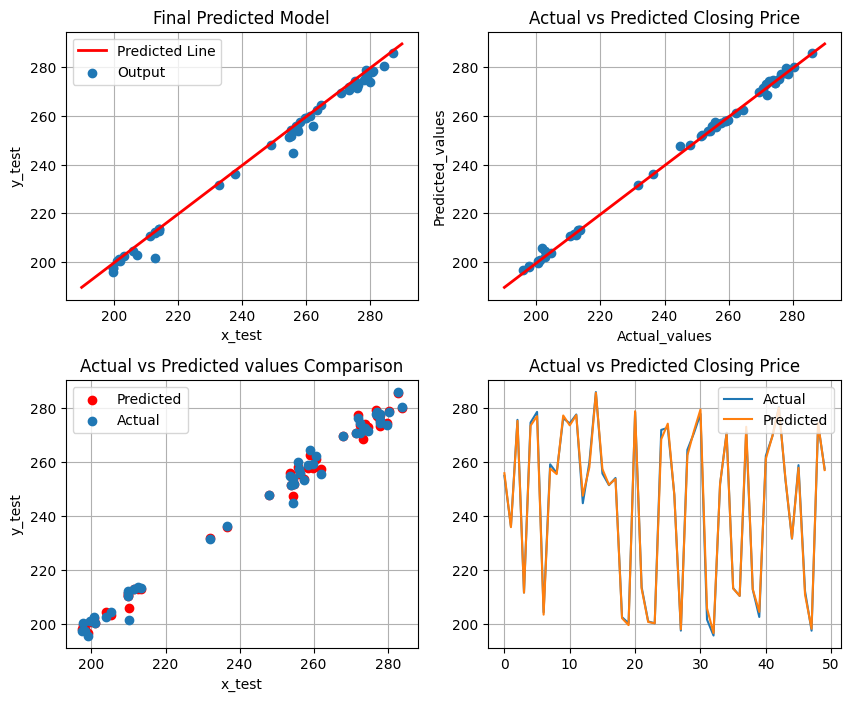

In [44]:
#y=mx+c ------- STRAIGHT LINE Equation

x=np.linspace(190,290,50)
y=(lr.coef_[0] * x) + (lr.coef_[1] * x) + (lr.coef_[2] * x) + (lr.coef_[3] * x) + lr.intercept_

plt.figure(figsize=(10,8))

#---------------Final Predicted Model-------------------------------------

plt.subplot(2,2,1)
plt.plot(x,y,color='r', linewidth=2, label='Predicted Line')
plt.scatter(x_test['High'], y_test, label='Output')
plt.xlabel('x_test')
plt.ylabel('y_test')
plt.title('Final Predicted Model') 
plt.grid(True)
plt.legend()
plt.gca().set_axisbelow(True)



#-------------------Actual vs Predicted values with Line------------------
plt.subplot(2,2,2)
plt.scatter(y_test,y_pred)
plt.plot(x,y,color='r', linewidth=2)
plt.xlabel('Actual_values')
plt.ylabel('Predicted_values')
plt.title('Actual vs Predicted Closing Price')

plt.grid(True)
plt.gca().set_axisbelow(True)



#----------------Actual vs Predicted values Comparison----------------------
plt.subplot(2,2,3)
plt.scatter(x_test['Open'],y_pred, color='r', label='Predicted')
plt.scatter(x_test['Open'], y_test, label='Actual')
plt.xlabel('x_test')
plt.ylabel('y_test')
plt.title('Actual vs Predicted values Comparison')
plt.legend()
plt.grid(True)
plt.gca().set_axisbelow(True)

plt.subplot(2,2,4)
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend(loc='upper right')
plt.title('Actual vs Predicted Closing Price')
plt.subplots_adjust(hspace=0.3)
plt.grid(True)
plt.gca().set_axisbelow(True)


<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
1: Splitted the input and output data into train and test parts. Trained the model using Linear Regression algorithm because output is numerical.

2: Evaluated the model after training the model. Calculated the R2_score, mean_squared_error, mean_absolute_error to analyze the output performanc eof the model.
Observed r2_score is 99% which is very well which mean model is predicitng 99% correct and just 1% is prediciting wrong output.Also errors are very small due to high accuracy of model.

3: Plotted the graphs:</span><br>
1st graph: On the x-axis is x_test, y-axis is y_test and plotted final predicted line. Observed model predicted line is exactly on the output, iti is alinged with the data which means model is working very well.</span><br>
2nd graph: Plotted the graph between actual and predicted values with the model predicted line. Graph is linear and line is exaclty lie on the values, actual ouput and model output is almost same.
</span><br>
3rd graph: Compared the actual output values and model predicted values .Observed model performance is very good, it is predicting almost similar to the actual values.
</span><br>
4th graph: Final plot is about the actual and predicted output(closing price). So we can see clearly Actual and Predicted graph are overlapping each other, it mean model output is similar to the original output present in the data.
</span><br>

<span style="color:black; font-weight:bold; font-size:18px;">Test the model using input values</span>

In [45]:
#test the model using input values
input_data = np.array([[212.03, 215.57, 208.16, 50229000]])
y_predict = lr.predict(input_data)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [46]:
y_predict

array([211.84293296])

df.loc[57]

Analyze the Distribution of Residual

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Tested the model by giving input to the model. Model predicted the output value is similar to the autual value present in the data.
</span><br>


<span style="color:black; font-weight:bold; font-size:18px;">Distribution of the Residual</span>

In [47]:
Residual=y_test-y_pred
Residual.mean()

np.float64(-0.001918145458400886)

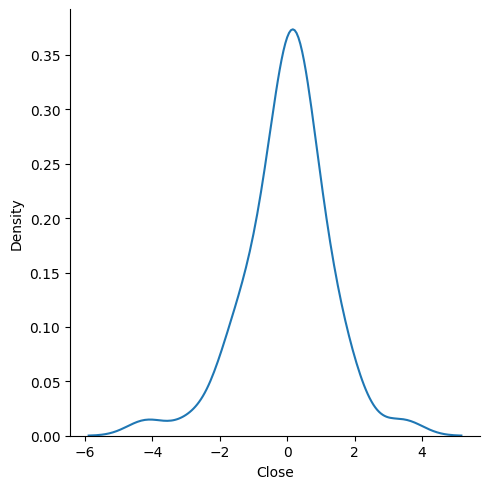

In [57]:
sb.displot(Residual, kind='kde')

In [49]:
y_test.values

array([254.97401428, 236.24969482, 275.65206909, 211.76559448,
       274.61999512, 278.58932495, 204.45890808, 259.20001221,
       255.99209595, 276.23150635, 274.35327148, 277.63021851,
       244.80340576, 259.88000488, 285.92245483, 255.77999878,
       251.49000549, 254.14559937, 202.65332031, 200.39019775,
       278.51937866, 213.74952698, 201.08807373, 200.39019775,
       271.93554688, 272.69485474, 247.99000549, 197.66847229,
       264.57998657, 270.7166748 , 277.85998535, 201.76600647,
       195.85400391, 251.83000183, 270.88366699, 213.40061951,
       210.5193634 , 271.58587646, 212.90211487, 202.733078  ,
       262.32003784, 269.52627563, 280.43759155, 253.55670166,
       231.69837952, 258.8999939 , 212.28399658, 197.64855957,
       273.85372925, 257.5690918 ])

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Plotted the residual graph to visualize the model. Observed graph is centered at zero (0) and it is normlay distributed which relfects that dat ais linear and model is good.
</span><br>
